In [30]:
import pandas as pd
data=pd.read_csv("/content/Dataset.csv")
df=pd.DataFrame(data)
df.head()
df.shape
df.dtypes
df.select_dtypes(include="number").columns.tolist()
df.select_dtypes(include=["object","category"]).columns.tolist()
df.isnull()
df.isnull().sum()
target_cols = ["CustomerID", "Age",  "Tenure", "Usage Frequency", "Support Calls", "Payment Delay",  "Total Spend", "Last Interaction", "Churn"]

df[target_cols] = df[target_cols].fillna(df[target_cols].mean(numeric_only=True))
df.info()
df.describe()



Training data loaded and initial numerical NaN values handled.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440833 non-null  float64
 1   Age                440833 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440833 non-null  float64
 4   Usage Frequency    440833 non-null  float64
 5   Support Calls      440833 non-null  float64
 6   Payment Delay      440833 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440833 non-null  float64
 10  Last Interaction   440833 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB
None


In [35]:
df.isnull()
df.isnull().sum()

df["Contract Length"].unique()
df["Subscription Type"].unique()
df["Gender"].unique()

categorical_columns=["Gender","Subscription Type","Contract Length"]
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode())


df.duplicated()
df.duplicated().sum()
df.drop_duplicates().shape[0]

for col in categorical_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip() # Strip spaces
print(df.info())

df["CustomerID"]=df["CustomerID"].astype(int)







<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440833 non-null  int64  
 1   Age                440833 non-null  float64
 2   Gender             440833 non-null  object 
 3   Tenure             440833 non-null  float64
 4   Usage Frequency    440833 non-null  float64
 5   Support Calls      440833 non-null  float64
 6   Payment Delay      440833 non-null  float64
 7   Subscription Type  440833 non-null  object 
 8   Contract Length    440833 non-null  object 
 9   Total Spend        440833 non-null  float64
 10  Last Interaction   440833 non-null  float64
 11  Churn              440833 non-null  int64  
dtypes: float64(7), int64(2), object(3)
memory usage: 40.4+ MB
None


In [34]:
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percentages)


df['Churn'] = df['Churn'].round().astype(int)


display(df['Churn'].value_counts())
display(df['Churn'].value_counts(normalize=True) * 100)

categorical_features = ['Gender', 'Subscription Type', 'Contract Length']

for feature in categorical_features:

    print(df[feature].value_counts())
    print(df[feature].value_counts(normalize=True) * 100)


Churn
1    250000
0    190833
Name: count, dtype: int64
Churn
1    56.710818
0    43.289182
Name: proportion, dtype: float64


,count
Churn,
1,250000
0,190833


,proportion
Churn,
1,56.710818
0,43.289182


Gender
Male      250252
Female    190580
nan            1
Name: count, dtype: int64
Gender
Male      56.767982
Female    43.231791
nan        0.000227
Name: proportion, dtype: float64
Subscription Type
Standard    149128
Premium     148678
Basic       143026
nan              1
Name: count, dtype: int64
Subscription Type
Standard    33.828683
Premium     33.726604
Basic       32.444486
nan          0.000227
Name: proportion, dtype: float64
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
nan               1
Name: count, dtype: int64
Contract Length
Annual       40.196174
Quarterly    40.044643
Monthly      19.758956
nan           0.000227
Name: proportion, dtype: float64


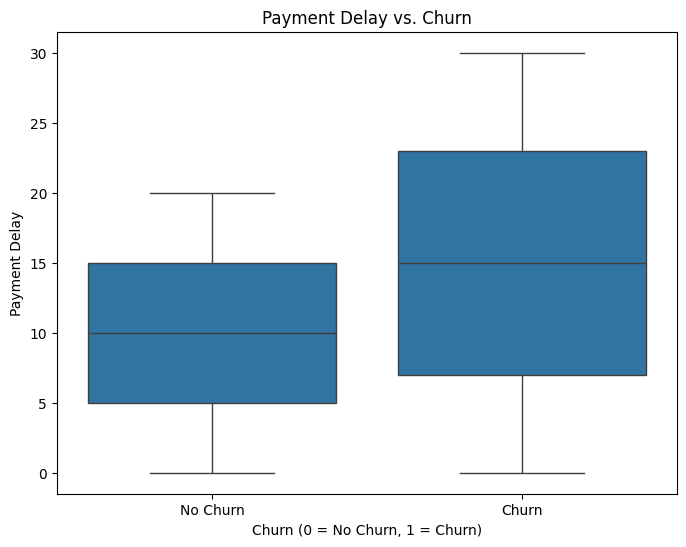

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Payment Delay', data=df)
plt.title('Payment Delay vs. Churn')
plt.xlabel('Churn (0 = No Churn, 1 = Churn)')
plt.ylabel('Payment Delay')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

X = df[['Usage Frequency', 'Payment Delay', 'Subscription Type',
        'Contract Length', 'Total Spend', 'Last Interaction']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 ... 1 0 0]
